# YouTube + Google Meet at 10 Mbps / 100 ms / pfifo

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('.').resolve()
COMBOS = ['youtube_solo', 'google_meet_solo', 'dual']

def load_jsonl(path):
    if not path.is_file():
        return []
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

def load_json(path):
    return json.loads(path.read_text()) if path.is_file() else {}

def qoe_window(combo):
    """(start, end) unix timestamps covering every app's QoE samples in a combo."""
    times = []
    for stats_file in (ROOT / combo).glob('*_stats.jsonl'):
        rows = load_jsonl(stats_file)
        if rows:
            times.append((rows[0]['timestamp'], rows[-1]['timestamp']))
    if not times:
        return None
    return min(t[0] for t in times), max(t[1] for t in times)


## Shaping verification

What was actually measured on the wire when each experiment applied its bottleneck, versus what was requested.

In [2]:
rows = []
for combo in COMBOS:
    shaping = load_json(ROOT / combo / 'shaping.json')
    bs = shaping.get('bottleneck_state', {})
    log = bs.get('verification_log', [])
    rows.append({
        'experiment': combo,
        'download_mbps (measured)': bs.get('download_mbps'),
        'latency_ms (configured)': bs.get('latency_ms'),
        'qdisc': bs.get('qdisc'),
        'buffer_packets': bs.get('buffer_packets'),
        'download_verify': next((l for l in log if l.startswith('download')), None),
        'latency_verify': next((l for l in log if l.startswith('latency')), None),
    })
pd.DataFrame(rows).set_index('experiment')


,download_mbps (measured),latency_ms (configured),qdisc,buffer_packets,download_verify,latency_verify
experiment,,,,,,
youtube_solo,10.0,100.0,pfifo,50,download: measured=9.08Mbps expected=10.0Mbps ...,latency: measured_rtt=146.01ms expected_rtt=10...
google_meet_solo,10.0,100.0,pfifo,50,download: measured=9.42Mbps expected=10.0Mbps ...,latency: measured_rtt=142.12ms expected_rtt=10...
dual,10.0,100.0,pfifo,50,download: measured=9.43Mbps expected=10.0Mbps ...,latency: measured_rtt=132.10ms expected_rtt=10...


## Achieved throughput

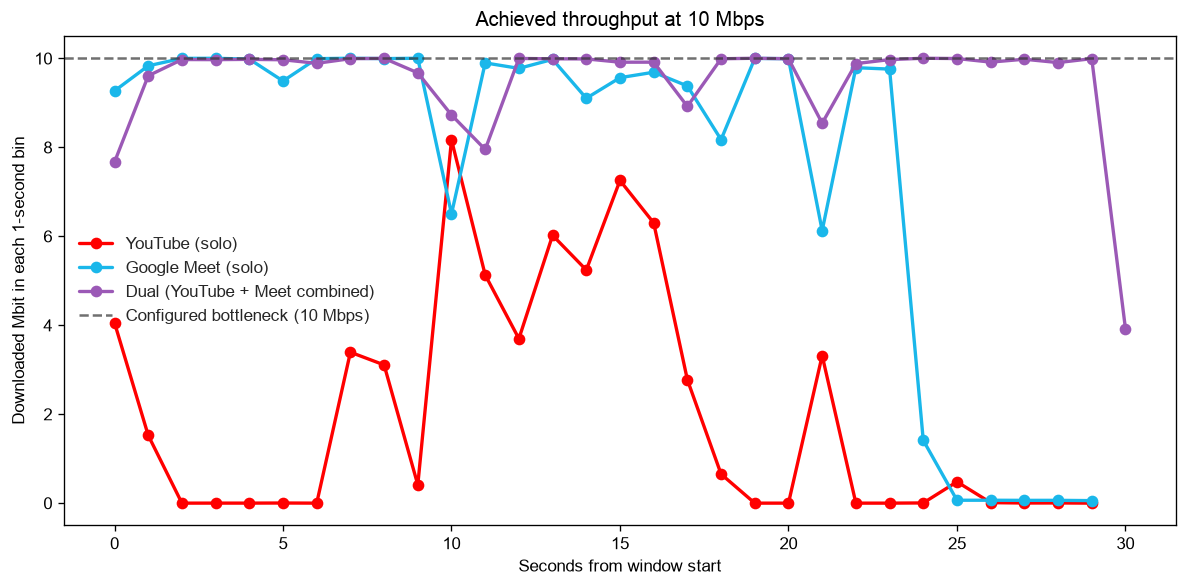

,average Mbps,peak 1-second Mbps,window (s)
experiment,,,
YouTube (solo),2.072,8.169,29.716
Google Meet (solo),7.624,10.004,29.913
Dual (YouTube + Meet combined),9.682,10.004,30.393


In [3]:
import subprocess

def throughput_series(combo):
    window = qoe_window(combo)
    if window is None:
        return None
    start, end = window
    pcaps = list((ROOT / combo).glob('*.pcap'))
    if not pcaps:
        return None
    out = subprocess.run(
        ['tshark', '-r', str(pcaps[0]), '-Y', 'ip.dst==172.16.1.1', '-T', 'fields',
         '-e', 'frame.time_epoch', '-e', 'frame.len'],
        check=True, capture_output=True, text=True,
    ).stdout
    per_second = {}
    for line in out.splitlines():
        fields = line.split('\t')
        if len(fields) >= 2 and fields[0] and fields[1]:
            t = float(fields[0])
            if start <= t <= end:
                second = int(t - start)
                per_second[second] = per_second.get(second, 0) + int(fields[1].split(',')[0])
    duration = end - start
    bins = range(0, int(duration) + 1)
    mbps = pd.Series({s: per_second.get(s, 0) * 8 / 1_000_000 for s in bins}).sort_index()
    return mbps, duration

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid')
summary_rows = []
labels = {'youtube_solo': 'YouTube (solo)', 'google_meet_solo': 'Google Meet (solo)', 'dual': 'Dual (YouTube + Meet combined)'}
colors = {'youtube_solo': '#ff0000', 'google_meet_solo': '#1ab7ea', 'dual': '#9b59b6'}
for combo in COMBOS:
    result = throughput_series(combo)
    if result is None:
        continue
    mbps, duration = result
    ax.plot(mbps.index, mbps.values, marker='o', linewidth=2, label=labels[combo], color=colors[combo])
    total_bytes_mbit = mbps.sum()
    summary_rows.append({
        'experiment': labels[combo],
        'average Mbps': total_bytes_mbit / duration if duration else None,
        'peak 1-second Mbps': mbps.max(),
        'window (s)': duration,
    })

ax.axhline(10, color='#333333', linestyle='--', alpha=.7, label='Configured bottleneck (10 Mbps)')
ax.set(
    title=f'Achieved throughput at 10 Mbps',
    xlabel='Seconds from window start',
    ylabel='Downloaded Mbit in each 1-second bin',
)
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows).set_index('experiment').round(3))


## YouTube playback QoE

**A confound to know about before reading the resolution chart below:** each run's
30-second measurement window starts only once page load finishes and playback is
confirmed advancing - so solo and dual runs can begin measuring at very different
points in the *video's own timeline* if one took longer to load than the other. The
x-axis below is video playback position (`current_time`), not wall-clock time since
sampling began, so it's visible exactly which portion of each run's playback lifecycle
is being shown.

In [4]:
startup_rows = []
for combo in ['youtube_solo', 'dual']:
    rows = load_jsonl(ROOT / combo / 'youtube_stats.jsonl')
    first_ct = (rows[0].get('stats') or {}).get('current_time_secs') if rows else None
    startup_rows.append({
        'experiment': combo,
        'video position at first sample (s)': first_ct,
    })
startup_df = pd.DataFrame(startup_rows).set_index('experiment')
display(startup_df)
if startup_df['video position at first sample (s)'].notna().all():
    solo_v = startup_df.loc['youtube_solo', 'video position at first sample (s)']
    dual_v = startup_df.loc['dual', 'video position at first sample (s)']
    print(f"Dual took playback ~{dual_v - solo_v:.1f}s further into the video to reach a confirmed-advancing state than solo did - "
          f"i.e. it took roughly that much longer to get through page load and player startup while sharing the link with Meet.")


,video position at first sample (s)
experiment,
youtube_solo,0.269087
dual,21.545579


Dual took playback ~21.3s further into the video to reach a confirmed-advancing state than solo did - i.e. it took roughly that much longer to get through page load and player startup while sharing the link with Meet.


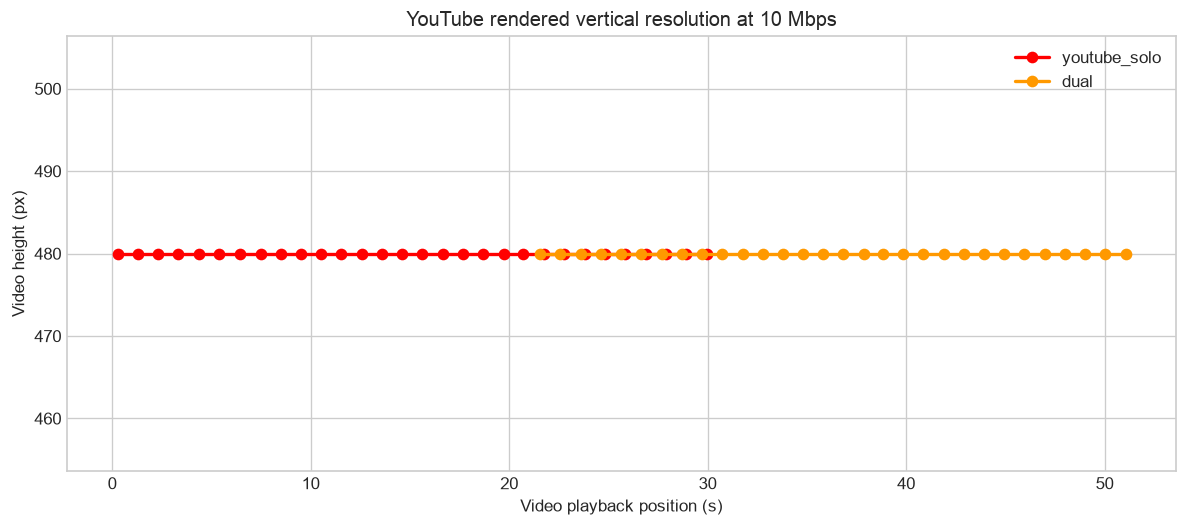

In [5]:
fig, ax_res = plt.subplots(figsize=(10, 4.5), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid')

any_data = False
for combo, color in [('youtube_solo', '#ff0000'), ('dual', '#ff9900')]:
    rows = load_jsonl(ROOT / combo / 'youtube_stats.jsonl')
    if not rows:
        continue
    position = [(r.get('stats') or {}).get('current_time_secs') for r in rows]
    res_h = [(r.get('stats') or {}).get('video_height') for r in rows]
    if any(v is not None for v in res_h):
        any_data = True
        ax_res.plot(position, res_h, marker='o', linewidth=2, label=combo, color=color)
    else:
        print(f'{combo}: no YouTube video ever attached (0 usable samples) - see the reasonableness note below.')

ax_res.set_title(f'YouTube rendered vertical resolution at 10 Mbps')
ax_res.set_ylabel('Video height (px)')
ax_res.set_xlabel('Video playback position (s)')
ax_res.legend()

plt.tight_layout()
plt.show()
if not any_data:
    print('No plottable YouTube data in this capacity folder (playback never started in every combo shown).')


## Google Meet call QoE

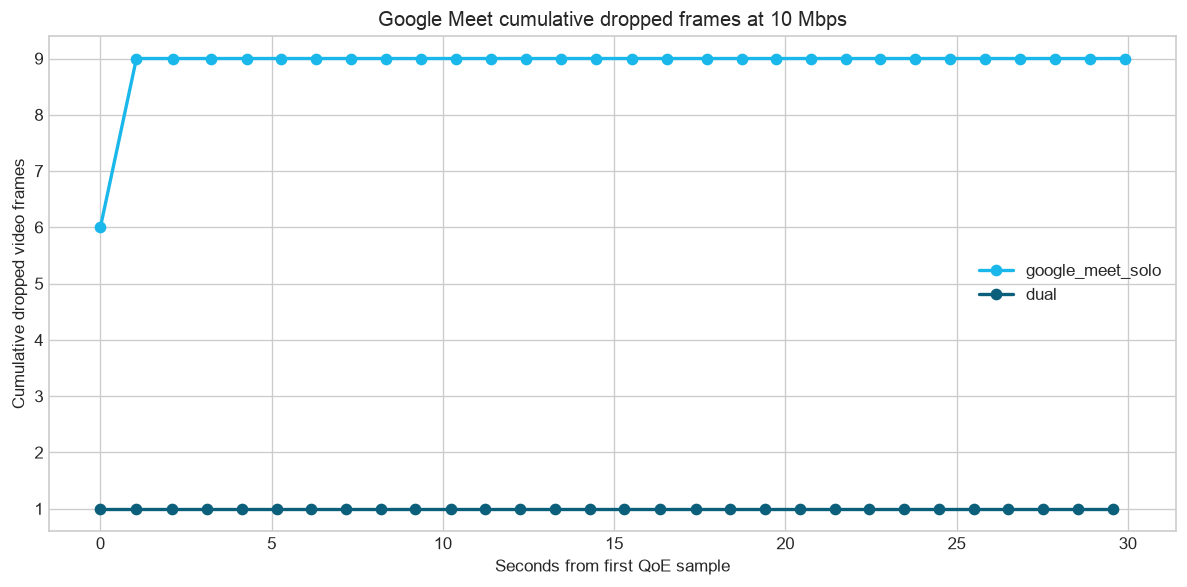

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

for combo, color in [('google_meet_solo', '#1ab7ea'), ('dual', '#0b5f7a')]:
    rows = load_jsonl(ROOT / combo / 'google_meet_stats.jsonl')
    if not rows:
        continue
    start = rows[0]['timestamp']
    seconds = [r['timestamp'] - start for r in rows]
    dropped = [(r.get('stats') or {}).get('dropped_video_frames') for r in rows]
    ax.plot(seconds, dropped, marker='o', linewidth=2, label=combo, color=color)

ax.set(
    title=f'Google Meet cumulative dropped frames at 10 Mbps',
    xlabel='Seconds from first QoE sample',
    ylabel='Cumulative dropped video frames',
)
ax.legend()
plt.tight_layout()
plt.show()


## Per-application traffic during the dual run

,download (MiB),average during window (Mbps),peak 1-second bin (Mbps),share of attributed bytes (%)
application,,,,
YouTube,3.459,0.955,1.385,92.455
Google Meet,0.282,0.078,0.987,7.545


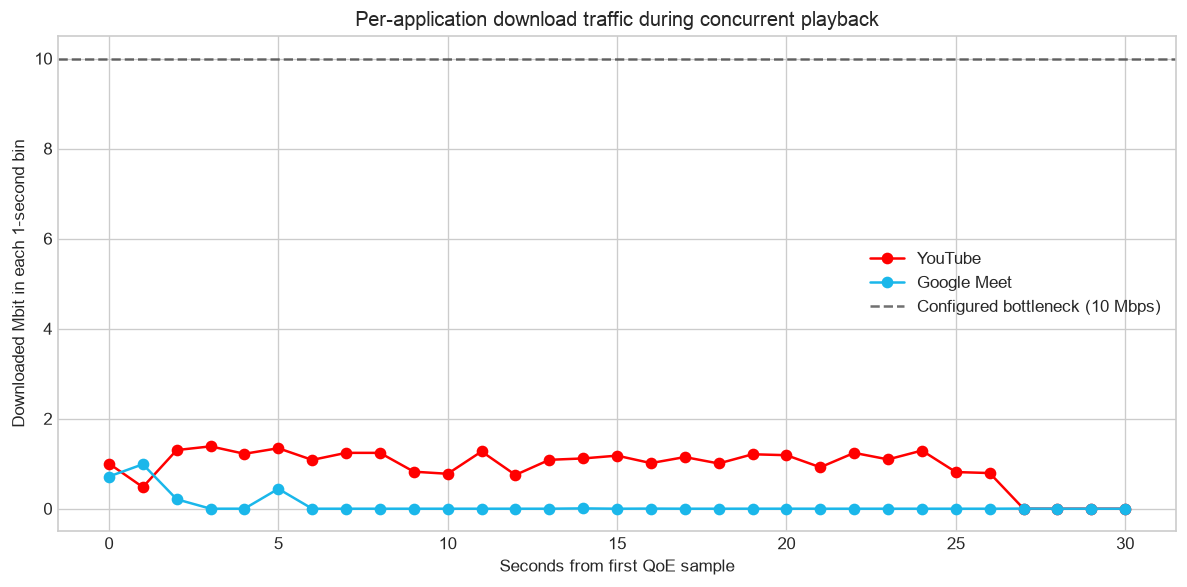

Attribution window: 30.393 seconds
App-attributed download: 3.741 MiB
Unattributed download (mostly ECH-protected flows): 31.338 MiB


In [7]:
import math

DUAL_DIR = ROOT / 'dual'
pcaps = list(DUAL_DIR.glob('*.pcap'))
if not pcaps:
    print('No dual-run PCAP found.')
else:
    PCAP = pcaps[0]
    CLIENT_IP = '172.16.1.1'

    def jsonl_bounds(path):
        rows = load_jsonl(path)
        return (rows[0]['timestamp'], rows[-1]['timestamp']) if rows else (None, None)

    bounds = [b for b in (jsonl_bounds(DUAL_DIR / f'{app}_stats.jsonl') for app in ('youtube', 'google_meet')) if b[0] is not None]
    window_start = min(b[0] for b in bounds)
    window_end = max(b[1] for b in bounds)
    window_seconds = window_end - window_start

    sni_output = subprocess.run(
        ['tshark', '-r', str(PCAP), '-Y', 'tls.handshake.extensions_server_name',
         '-T', 'fields', '-e', 'ip.dst', '-e', 'tls.handshake.extensions_server_name'],
        check=True, capture_output=True, text=True,
    ).stdout
    hosts_by_ip = {}
    for line in sni_output.splitlines():
        fields = line.split('\t')
        if len(fields) >= 2 and fields[0] and fields[1]:
            hosts_by_ip.setdefault(fields[0], set()).update(h.lower() for h in fields[1].split(','))

    youtube_markers = ('youtube.com', 'googlevideo.com', 'ytimg.com', 'ggpht.com', 'gvt1.com')
    meet_markers = ('meet.google.com',)
    youtube_ips = {ip for ip, hosts in hosts_by_ip.items() if any(m in h for h in hosts for m in youtube_markers)}
    meet_ips = {ip for ip, hosts in hosts_by_ip.items() if any(m in h for h in hosts for m in meet_markers)}

    packet_output = subprocess.run(
        ['tshark', '-r', str(PCAP), '-Y', f'ip.dst == {CLIENT_IP}', '-T', 'fields',
         '-e', 'frame.time_epoch', '-e', 'ip.src', '-e', 'frame.len'],
        check=True, capture_output=True, text=True,
    ).stdout
    packet_rows = []
    for line in packet_output.splitlines():
        fields = line.split('\t')
        if len(fields) >= 3 and all(fields[:3]):
            timestamp, remote_ip, frame_bytes = float(fields[0]), fields[1], int(fields[2].split(',')[0])
            if window_start <= timestamp <= window_end:
                app = 'YouTube' if remote_ip in youtube_ips else 'Google Meet' if remote_ip in meet_ips else 'Unclassified'
                packet_rows.append((timestamp, remote_ip, frame_bytes, app))

    packets = pd.DataFrame(packet_rows, columns=['timestamp', 'remote_ip', 'frame_bytes', 'application'])
    packets['second'] = (packets.timestamp - window_start).astype(int)
    bin_count = max(1, math.ceil(window_seconds))
    app_bytes = (packets[packets.application.isin(['YouTube', 'Google Meet'])]
                 .groupby(['second', 'application']).frame_bytes.sum()
                 .unstack(fill_value=0)
                 .reindex(range(bin_count), fill_value=0)
                 .reindex(columns=['YouTube', 'Google Meet'], fill_value=0))
    app_mbps = app_bytes * 8 / 1_000_000

    summary_rows = []
    total_attributed = app_bytes.to_numpy().sum()
    for app in ['YouTube', 'Google Meet']:
        total_bytes = app_bytes[app].sum()
        summary_rows.append({
            'application': app,
            'download (MiB)': total_bytes / 2**20,
            'average during window (Mbps)': total_bytes * 8 / window_seconds / 1_000_000 if window_seconds else None,
            'peak 1-second bin (Mbps)': app_mbps[app].max(),
            'share of attributed bytes (%)': 100 * total_bytes / total_attributed if total_attributed else None,
        })
    display(pd.DataFrame(summary_rows).set_index('application').round(3))

    fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
    ax.plot(app_mbps.index, app_mbps['YouTube'], marker='o', color='#ff0000', label='YouTube')
    ax.plot(app_mbps.index, app_mbps['Google Meet'], marker='o', color='#1ab7ea', label='Google Meet')
    ax.axhline(10, color='#333333', linestyle='--', alpha=.7, label='Configured bottleneck (10 Mbps)')
    ax.set(
        title='Per-application download traffic during concurrent playback',
        xlabel='Seconds from first QoE sample',
        ylabel='Downloaded Mbit in each 1-second bin',
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    unclassified = packets.loc[packets.application == 'Unclassified', 'frame_bytes'].sum()
    print(f'Attribution window: {window_seconds:.3f} seconds')
    print(f'App-attributed download: {total_attributed / 2**20:.3f} MiB')
    print(f'Unattributed download (mostly ECH-protected flows): {unclassified / 2**20:.3f} MiB')
